# Tutorial: Scikit-learn Financial Machine Learning Mastery Guide

Audience:
- Learners who know basic machine-learning concepts and want a clear map of scikit-learn's main model families.
- Financial-engineering students who want to compare models on reproducible, finance-inspired synthetic data.

Prerequisites:
- Python, NumPy, pandas, and basic plotting.
- The ideas of regression, classification, train/test splits, and overfitting.

Learning goals:
- Use scikit-learn's common `fit` / `predict` workflow with confidence.
- Understand the main estimator families and their high-impact parameters.
- Build leakage-safe pipelines for regression and classification.
- Select models with cross-validation and grid search.
- Know when time-ordered data requires `TimeSeriesSplit` instead of random splitting.
- Use PCA and K-Means for compact unsupervised analysis.
    

## Outline

1. Create one synthetic financial-feature dataset
2. Learn the estimator and pipeline mental model
3. Compare regression models for next-period returns
4. Compare classification models for return direction
5. Use cross-validation, grid search, and time-aware validation
6. Inspect feature importance and coefficients
7. Use PCA and K-Means for unsupervised structure

The notebook deliberately focuses on the estimators most useful for everyday tabular machine-learning work. Scikit-learn contains more specialised models, but these families give you a strong working map of the library.
    

In [1]:
from __future__ import annotations

# If needed, uncomment the next line in your notebook kernel.
# %pip install numpy pandas matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, KFold, TimeSeriesSplit, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeRegressor

SEED = 42
rng = np.random.default_rng(SEED)

import sklearn

print("scikit-learn version:", sklearn.__version__)
print("Seed:", SEED)
    

scikit-learn version: 1.8.0
Seed: 42


## Step 1 - Create synthetic financial-style data

Each row is one business day. The feature columns are deliberately plausible market signals: momentum, volatility, value, liquidity, carry, market beta, and a macro proxy. The targets are:

- `next_return`: a continuous next-period excess return for regression;
- `next_direction`: whether that return is positive for classification.

These are illustrative signals, not an investment strategy or a claim about real predictive relationships.
    

In [2]:
n_days = 1_400
dates = pd.bdate_range("2020-01-01", periods=n_days)
time = np.arange(n_days)

# Smooth regime components make the data feel time-ordered rather than i.i.d.
market_regime = 0.8 * np.sin(time / 90) + 0.3 * np.sin(time / 25)
volatility_regime = 0.6 + 0.35 * np.cos(time / 70)

features = pd.DataFrame(
    {
        "momentum_20d": 0.7 * market_regime + rng.normal(0, 0.8, n_days),
        "momentum_60d": 0.9 * market_regime + rng.normal(0, 0.6, n_days),
        "realized_volatility": volatility_regime + rng.normal(0, 0.18, n_days),
        "value_spread": rng.normal(0, 1.0, n_days),
        "liquidity_score": rng.normal(0, 1.0, n_days),
        "carry_signal": 0.4 * np.sin(time / 45) + rng.normal(0, 0.7, n_days),
        "market_beta": rng.normal(1.0, 0.25, n_days),
        "macro_surprise": rng.normal(0, 1.0, n_days),
    },
    index=dates,
)

# Linear, non-linear, and interaction effects give different models something to learn.
next_return = (
    0.007 * features["momentum_20d"]
    + 0.004 * features["value_spread"]
    + 0.003 * features["carry_signal"]
    - 0.006 * features["realized_volatility"]
    + 0.004 * features["momentum_20d"] * features["liquidity_score"]
    - 0.003 * features["market_beta"].pow(2)
    + 0.002 * np.sin(features["macro_surprise"])
    + rng.normal(0, 0.012, n_days)
)

target_return = next_return.rename("next_return")
target_direction = (target_return > target_return.median()).astype(int).rename("next_direction")

print("Feature matrix:", features.shape)
print(f"Positive-direction rate: {target_direction.mean():.1%}")
pd.concat([features, target_return, target_direction], axis=1).head()
    

Feature matrix: (1400, 8)
Positive-direction rate: 50.0%


,momentum_20d,momentum_60d,realized_volatility,value_spread,liquidity_score,carry_signal,market_beta,macro_surprise,next_return,next_direction
2020-01-01,0.243774,0.709518,0.903269,-0.809099,1.689823,-1.022508,0.880416,-0.010745,-0.015781,0
2020-01-02,-0.817367,-0.175594,1.124529,-1.989168,1.342182,-0.614538,1.289774,-1.341057,-0.038746,0
2020-01-03,0.629586,-0.084866,1.107227,0.540610,0.632839,-0.485659,0.901816,0.386858,-0.013744,0
2020-01-06,0.796255,-0.238676,0.772935,2.120081,0.378467,-0.118829,1.157977,-1.878285,-0.009509,0
2020-01-07,-1.502491,-0.273385,0.795434,1.389560,-0.087959,-0.497215,1.044891,0.348310,-0.012560,0


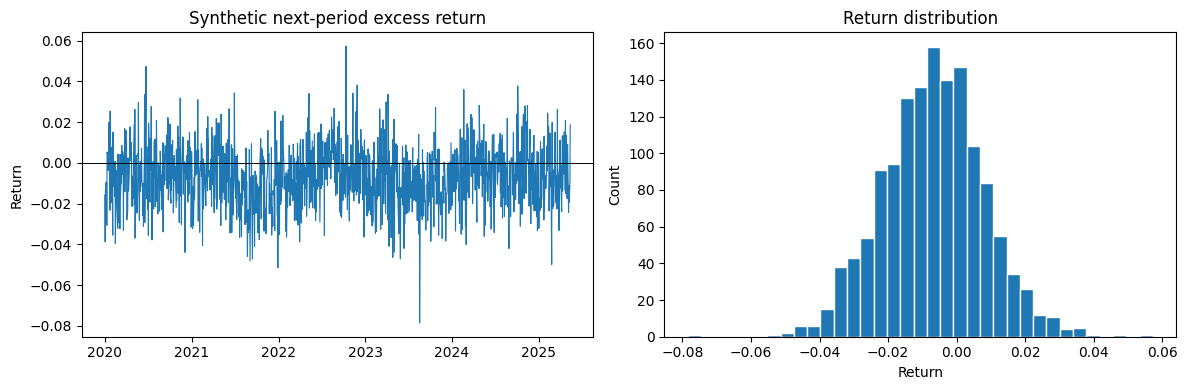

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(target_return.index, target_return, linewidth=0.8)
axes[0].axhline(0, color="black", linewidth=0.7)
axes[0].set(title="Synthetic next-period excess return", ylabel="Return")

axes[1].hist(target_return, bins=35, edgecolor="white")
axes[1].set(title="Return distribution", xlabel="Return", ylabel="Count")

plt.tight_layout()
plt.show()
    

## Step 2 - The scikit-learn mental model

Most scikit-learn objects follow the same compact API:

| Method | Meaning |
|---|---|
| `fit(X, y)` | Learn parameters from training data. |
| `predict(X)` | Produce regression values or class labels. |
| `predict_proba(X)` | Produce class probabilities when a classifier supports it. |
| `transform(X)` | Convert features, for example with scaling or PCA. |
| `fit_transform(X)` | Learn a transformation and apply it to the same training data. |
| `get_params()` / `set_params()` | Inspect or update constructor parameters; this is how searches tune a model. |

An **estimator** is any object with `fit`. A **transformer** changes `X`; a **predictor** produces predictions. `Pipeline` connects them safely.
    

In [4]:
ridge_example = Ridge(alpha=1.0)

# Constructor parameters are visible and searchable.
important_ridge_parameters = {
    name: value
    for name, value in ridge_example.get_params().items()
    if name in {"alpha", "fit_intercept", "tol", "max_iter"}
}
important_ridge_parameters
    

{'alpha': 1.0, 'fit_intercept': True, 'max_iter': None, 'tol': 0.0001}

### Why pipelines matter

Scaling is essential for distance-based, margin-based, and regularised linear models. A pipeline ensures the scaler is fitted only on each training fold and then applied to validation/test data. This prevents leakage and keeps your model object portable.

Tree-based models normally do not need scaling because they split on feature thresholds rather than Euclidean distance or coefficient size.
    

In [5]:
# This is the standard pattern: preprocessing first, predictor last.
ridge_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]
)

# Pipeline parameters use step_name + two underscores + parameter_name.
ridge_pipeline.set_params(model__alpha=2.0)
ridge_pipeline
    

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",2.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


## Step 3 - A normal train/test split for model comparisons

We start with a random split so every model sees the same simple train/test problem. This is useful for learning the estimator families. Later, we revisit the ordered data with `TimeSeriesSplit`, which is the appropriate tool when future observations must remain unseen.
    

In [6]:
X_train, X_test, y_return_train, y_return_test, y_direction_train, y_direction_test = train_test_split(
    features,
    target_return,
    target_direction,
    test_size=0.25,
    random_state=SEED,
    stratify=target_direction,
)

print("Train rows:", len(X_train))
print("Test rows: ", len(X_test))
    

Train rows: 1050
Test rows:  350


## Step 4 - Regression models: predict the next return

The following table is a practical map of the main regression families. Use it as a first reference, then let cross-validation decide for a real dataset.

| Family | Typical use | High-impact parameters |
|---|---|---|
| `LinearRegression` | Transparent unregularised baseline | `fit_intercept`: include a constant term. |
| `Ridge` | Correlated features; stable linear model | `alpha`: L2 regularisation strength; larger values shrink all coefficients more. |
| `Lasso` | Sparse linear selection | `alpha`: L1 strength; larger values can set coefficients exactly to zero. |
| `ElasticNet` | Mix of Ridge and Lasso | `alpha`: total regularisation; `l1_ratio`: 0 = Ridge-like, 1 = Lasso-like. |
| `KNeighborsRegressor` | Local, non-linear patterns | `n_neighbors`: neighbourhood size; `weights`: uniform or distance weighting; `p`: distance geometry. |
| `SVR` | Flexible smooth margins on modest datasets | `C`: error penalty; `epsilon`: no-penalty tube; `gamma`: RBF kernel reach. |
| `DecisionTreeRegressor` | Simple non-linear rules | `max_depth`: tree complexity; `min_samples_leaf`: minimum leaf size. |
| `RandomForestRegressor` | Robust non-linear ensemble baseline | `n_estimators`: number of trees; `max_features`: features per split; `min_samples_leaf`: smoothing. |
| `HistGradientBoostingRegressor` | Strong tabular baseline, often faster than classic boosting | `learning_rate`: step size; `max_iter`: number of boosting rounds; `max_leaf_nodes`: tree complexity; `l2_regularization`: shrinkage. |
    

In [7]:
regression_models = {
    "Linear regression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge": Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=2.0))]),
    "Lasso": Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=0.002, max_iter=10_000))]),
    "Elastic Net": Pipeline(
        [("scaler", StandardScaler()), ("model", ElasticNet(alpha=0.002, l1_ratio=0.5, max_iter=10_000))]
    ),
    "K-nearest neighbours": Pipeline(
        [("scaler", StandardScaler()), ("model", KNeighborsRegressor(n_neighbors=25, weights="distance"))]
    ),
    "SVR (RBF kernel)": Pipeline(
        [("scaler", StandardScaler()), ("model", SVR(C=1.0, epsilon=0.01, gamma="scale"))]
    ),
    "Decision tree": DecisionTreeRegressor(max_depth=5, min_samples_leaf=15, random_state=SEED),
    "Random forest": RandomForestRegressor(
        n_estimators=250,
        min_samples_leaf=8,
        max_features=0.8,
        random_state=SEED,
        n_jobs=-1,
    ),
    "Histogram gradient boosting": HistGradientBoostingRegressor(
        learning_rate=0.06,
        max_iter=250,
        max_leaf_nodes=15,
        l2_regularization=0.5,
        random_state=SEED,
    ),
}
    

In [8]:
def regression_report(models: dict, X_train, y_train, X_test, y_test) -> pd.DataFrame:
    rows = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        prediction = model.predict(X_test)

        rows.append(
            {
                "model": name,
                "MAE": mean_absolute_error(y_test, prediction),
                "RMSE": np.sqrt(mean_squared_error(y_test, prediction)),
                "R2": r2_score(y_test, prediction),
            }
        )

    return pd.DataFrame(rows).sort_values("MAE").reset_index(drop=True)


regression_results = regression_report(
    regression_models,
    X_train,
    y_return_train,
    X_test,
    y_return_test,
)
regression_results.style.format({"MAE": "{:.4f}", "RMSE": "{:.4f}", "R2": "{:.3f}"})
    

,model,MAE,RMSE,R2
0,Linear regression,0.0100,0.0129,0.310
1,Ridge,0.0100,0.0129,0.310
2,Random forest,0.0101,0.0128,0.319
3,Elastic Net,0.0102,0.0132,0.278
4,Histogram gradient boosting,0.0105,0.0132,0.275
5,K-nearest neighbours,0.0106,0.0134,0.257
6,Lasso,0.0109,0.0138,0.208
7,Decision tree,0.0109,0.0138,0.207
8,SVR (RBF kernel),0.0129,0.0165,-0.135


### Read the regression comparison carefully

A lower MAE/RMSE is better; a higher R² is better. The synthetic target contains non-linear interactions, so ensembles and kernels have an advantage. That does not make them automatically preferable in practice: financial data changes through time, can be noisy, and often rewards a stable, interpretable baseline.
    

In [9]:
# Coefficients are available for linear models after fitting.
fitted_ridge = regression_models["Ridge"]
ridge_coefficients = pd.Series(
    fitted_ridge.named_steps["model"].coef_,
    index=features.columns,
    name="standardised Ridge coefficient",
).sort_values(key=np.abs, ascending=False)

ridge_coefficients.to_frame()
    

,standardised Ridge coefficient
momentum_20d,0.005983
value_spread,0.003912
realized_volatility,-0.001934
carry_signal,0.001884
macro_surprise,0.001671
market_beta,-0.001588
liquidity_score,0.000328
momentum_60d,-0.000310


## Step 5 - Classification models: predict return direction

Classification predicts a class, not the return size. Here, `1` means positive next-period return. Accuracy is useful when classes are balanced; ROC AUC is useful for judging how well predicted probabilities rank positives above negatives.

| Family | Typical use | High-impact parameters |
|---|---|---|
| `LogisticRegression` | Strong, interpretable probability baseline | `C`: inverse regularisation (smaller = more regularisation); `penalty`: L1/L2 style; `class_weight`: handle imbalance. |
| `KNeighborsClassifier` | Local class structure | `n_neighbors`, `weights`, and `p` have the same meaning as in KNN regression. |
| `SVC` | Margin-based non-linear classification | `C`: margin/error trade-off; `kernel`: geometry; `gamma`: RBF reach; `probability=True`: enables probabilities but adds work. |
| `RandomForestClassifier` | Robust non-linear ensemble | `n_estimators`, `max_features`, `min_samples_leaf`, and `class_weight`. |
| `HistGradientBoostingClassifier` | Efficient boosted trees for tabular data | `learning_rate`, `max_iter`, `max_leaf_nodes`, and `l2_regularization`. |
    

In [10]:
classification_models = {
    "Logistic regression": Pipeline(
        [("scaler", StandardScaler()), ("model", LogisticRegression(C=1.0, max_iter=2_000))]
    ),
    "K-nearest neighbours": Pipeline(
        [("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=35, weights="distance"))]
    ),
    "SVC (RBF kernel)": Pipeline(
        [("scaler", StandardScaler()), ("model", SVC(C=1.0, gamma="scale", probability=True, random_state=SEED))]
    ),
    "Random forest": RandomForestClassifier(
        n_estimators=250,
        min_samples_leaf=8,
        max_features=0.8,
        random_state=SEED,
        n_jobs=-1,
    ),
    "Histogram gradient boosting": HistGradientBoostingClassifier(
        learning_rate=0.06,
        max_iter=250,
        max_leaf_nodes=15,
        l2_regularization=0.5,
        random_state=SEED,
    ),
}
    

In [11]:
def classification_report_table(models: dict, X_train, y_train, X_test, y_test) -> pd.DataFrame:
    rows = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        predicted_class = model.predict(X_test)
        predicted_probability = model.predict_proba(X_test)[:, 1]

        rows.append(
            {
                "model": name,
                "accuracy": accuracy_score(y_test, predicted_class),
                "ROC AUC": roc_auc_score(y_test, predicted_probability),
            }
        )

    return pd.DataFrame(rows).sort_values("ROC AUC", ascending=False).reset_index(drop=True)


classification_results = classification_report_table(
    classification_models,
    X_train,
    y_direction_train,
    X_test,
    y_direction_test,
)
classification_results.style.format({"accuracy": "{:.1%}", "ROC AUC": "{:.3f}"})
    

,model,accuracy,ROC AUC
0,Logistic regression,69.1%,0.761
1,Random forest,68.0%,0.754
2,SVC (RBF kernel),66.3%,0.739
3,K-nearest neighbours,66.0%,0.736
4,Histogram gradient boosting,66.0%,0.719


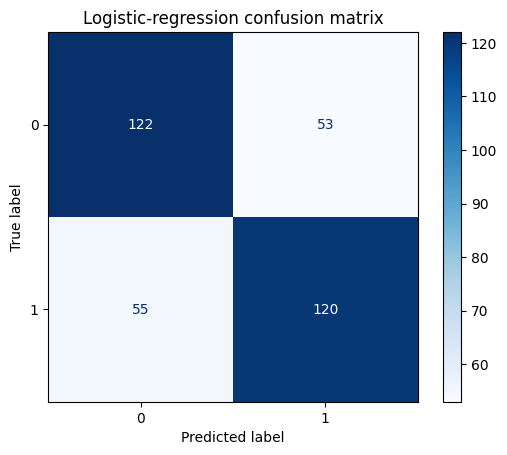

In [12]:
# A confusion matrix uses a selected hard threshold (0.5 by default for predict()).
fitted_logistic = classification_models["Logistic regression"]
ConfusionMatrixDisplay.from_estimator(fitted_logistic, X_test, y_direction_test, cmap="Blues")
plt.title("Logistic-regression confusion matrix")
plt.show()
    

## Step 6 - Cross-validation and hyperparameter search

A single train/test result can be lucky. Cross-validation repeats the train/validation split and estimates how sensitive performance is to the sample. `GridSearchCV` applies this process to every parameter combination in a grid.

The pipeline is passed directly to both tools. This is important: `StandardScaler` is then fitted separately inside each training fold rather than leaking information across folds.
    

In [13]:
shuffled_cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
ridge_cv_scores = cross_val_score(
    Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=2.0))]),
    features,
    target_return,
    cv=shuffled_cv,
    scoring="neg_mean_absolute_error",
)

mae_scores = -ridge_cv_scores
print(f"Five-fold MAE: {mae_scores.mean():.4f} ± {mae_scores.std():.4f}")
    

Five-fold MAE: 0.0098 ± 0.0004


In [14]:
ridge_search = GridSearchCV(
    estimator=Pipeline([("scaler", StandardScaler()), ("model", Ridge())]),
    param_grid={"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    scoring="neg_mean_absolute_error",
    cv=shuffled_cv,
    n_jobs=-1,
)

ridge_search.fit(X_train, y_return_train)
print("Best Ridge parameters:", ridge_search.best_params_)
print(f"Best cross-validated MAE: {-ridge_search.best_score_:.4f}")

tuned_ridge_prediction = ridge_search.predict(X_test)
print(f"Untouched test MAE: {mean_absolute_error(y_return_test, tuned_ridge_prediction):.4f}")
    

Best Ridge parameters: {'model__alpha': 10.0}
Best cross-validated MAE: 0.0097
Untouched test MAE: 0.0100


### `TimeSeriesSplit` for ordered data

Random K-fold cross-validation mixes future and past rows. For financial time series, use expanding time splits: train on older observations and validate on the next block. In real research, also make sure each feature is itself constructed without using future prices or fundamentals.
    

In [15]:
time_cv = TimeSeriesSplit(n_splits=5)
time_series_pipeline = Pipeline(
    [("scaler", StandardScaler()), ("model", Ridge(alpha=2.0))]
)

time_cv_scores = cross_val_score(
    time_series_pipeline,
    features,
    target_return,
    cv=time_cv,
    scoring="neg_mean_absolute_error",
)

time_mae = -time_cv_scores
print("Walk-forward-style validation MAE by fold:", np.round(time_mae, 4))
print(f"Average time-aware MAE: {time_mae.mean():.4f}")
    

Walk-forward-style validation MAE by fold: [0.0115 0.0095 0.0097 0.0094 0.0093]
Average time-aware MAE: 0.0099


## Step 7 - Interpret fitted models with care

Linear coefficients are direct and compact after scaling. Tree impurity importances are quick but can be misleading with correlated features. Permutation importance is often safer: it measures the drop in a chosen score after shuffling one feature on held-out data.
    

In [16]:
fitted_forest = regression_models["Random forest"]
forest_importance = permutation_importance(
    fitted_forest,
    X_test,
    y_return_test,
    scoring="neg_mean_absolute_error",
    n_repeats=20,
    random_state=SEED,
    n_jobs=-1,
)

importance_table = pd.DataFrame(
    {
        "feature": features.columns,
        "mean_MAE_increase": forest_importance.importances_mean,
        "std": forest_importance.importances_std,
    }
).sort_values("mean_MAE_increase", ascending=False)

importance_table
    

,feature,mean_MAE_increase,std
0,momentum_20d,2.457580e-03,0.000202
3,value_spread,8.217232e-04,0.000233
4,liquidity_score,4.277912e-04,0.000102
5,carry_signal,2.414679e-04,0.000102
2,realized_volatility,1.151829e-04,0.000078
6,market_beta,8.960576e-05,0.000054
1,momentum_60d,2.451041e-07,0.000025
7,macro_surprise,-1.541902e-05,0.000053


## Step 8 - PCA and K-Means: useful unsupervised tools

`PCA` finds orthogonal components that explain variance in scaled features. It is useful for visualisation, compression, and identifying common factors; it is not a supervised predictor by itself.

`KMeans` assigns observations to `n_clusters` groups by minimising within-cluster squared distance. It is useful for exploratory regime grouping, but cluster labels are arbitrary and do not imply a trading rule.

| Tool | High-impact parameters |
|---|---|
| `PCA` | `n_components`: count of components or target explained-variance fraction; `whiten`: rescale components (usually leave `False`). |
| `KMeans` | `n_clusters`: chosen number of groups; `n_init`: independent initialisations; `max_iter`: maximum update rounds; `random_state`: reproducible starts. |
    

Explained variance by PC1 and PC2: [0.171 0.133]
Total explained variance: 30.4%


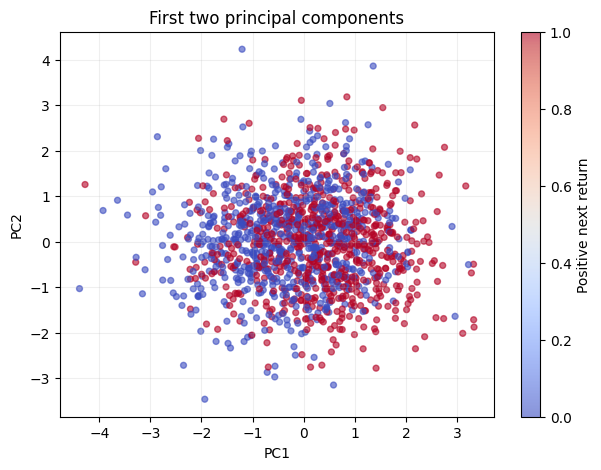

In [17]:
scaled_features = StandardScaler().fit_transform(features)

pca = PCA(n_components=2, random_state=SEED)
principal_components = pca.fit_transform(scaled_features)

print("Explained variance by PC1 and PC2:", np.round(pca.explained_variance_ratio_, 3))
print("Total explained variance:", f"{pca.explained_variance_ratio_.sum():.1%}")

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    principal_components[:, 0],
    principal_components[:, 1],
    c=target_direction,
    cmap="coolwarm",
    alpha=0.6,
    s=18,
)
plt.colorbar(scatter, label="Positive next return")
plt.title("First two principal components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.2)
plt.show()
    

In [18]:
kmeans = KMeans(n_clusters=3, n_init=20, random_state=SEED)
cluster_labels = kmeans.fit_predict(scaled_features)

cluster_summary = (
    pd.DataFrame(
        {
            "cluster": cluster_labels,
            "next_return": target_return.to_numpy(),
            "realized_volatility": features["realized_volatility"].to_numpy(),
        }
    )
    .groupby("cluster")
    .agg(
        observations=("cluster", "size"),
        mean_next_return=("next_return", "mean"),
        mean_volatility=("realized_volatility", "mean"),
    )
    .round(4)
)

print("K-Means inertia:", round(kmeans.inertia_, 1))
cluster_summary
    

K-Means inertia: 9276.4


,observations,mean_next_return,mean_volatility
cluster,,,
0,445,-0.0058,0.5269
1,505,-0.0131,0.7289
2,450,-0.0011,0.5819


## Common mistakes to remember

- **Scaling before splitting:** fit `StandardScaler` inside a pipeline so only training folds determine means and standard deviations.
- **Treating `alpha` and `C` as the same direction:** Ridge/Lasso/ElasticNet use larger `alpha` for stronger regularisation; Logistic Regression/SVC use smaller `C` for stronger regularisation.
- **Using a deep tree with tiny leaves:** it can memorise training noise; constrain `max_depth` or increase `min_samples_leaf`.
- **Using default KNN on unscaled features:** a large-scale feature dominates distance.
- **Tuning repeatedly on the test set:** use cross-validation or validation data, then inspect the test set once.
- **Randomly splitting time-series data:** it leaks temporal structure. Use `TimeSeriesSplit` or a walk-forward backtest.
- **Reading feature importance as causality:** importance measures predictive contribution under the fitted model, not an economic cause.
    

## Final takeaway

The most reusable scikit-learn pattern is:

1. build a feature matrix `X` and target `y`;
2. choose a leakage-safe split strategy;
3. put necessary preprocessing and the model in a `Pipeline`;
4. call `fit`, `predict`, and the appropriate metric;
5. compare sensible model families with cross-validation;
6. tune only the important parameters, then assess one final untouched test or walk-forward result.

Keep linear models as transparent baselines, use trees/boosting for non-linear tabular patterns, use SVM/KNN only after scaling, and use PCA/K-Means as exploratory tools rather than automatic answers. The official [scikit-learn user guide](https://scikit-learn.org/stable/user_guide.html) is the best next reference when you need a specialised estimator.
    